# tap.ladder~ — virtual-analog transistor ladder verification

`tap.ladder~` is a zero-delay-feedback TPT model of the classic 4-stage transistor
ladder with a tanh saturator in every stage: prewarped tuning that stays accurate
into the top octaves, clean bounded self-oscillation, a drive control into the
nonlinearity, Oberheim-Xpander-style pole-mixed multimode outputs, and 1/2/4×
oversampling (2× default).

This notebook machine-checks those claims against the **actual C++ kernel**
(`include/taptools/ladder.h` — the header `tap.ladder~` compiles) through the C ABI.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def spectrum_db(y, sr=fs):
    """Hann-windowed magnitude spectrum in dBFS-ish units."""
    n = len(y)
    w = np.hanning(n)
    Y = np.abs(np.fft.rfft(y * w)) / (np.sum(w) / 2)
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(Y + 1e-12)


def db_at(freqs, db, hz):
    return float(np.interp(hz, freqs, db))


def peak_freq(y, sr=fs, fmin=20.0):
    """Dominant frequency via parabolic interpolation on the windowed FFT peak."""
    freqs, db = spectrum_db(y, sr)
    sel = freqs >= fmin
    i = np.argmax(db[sel]) + np.searchsorted(freqs, fmin)
    if 0 < i < len(db) - 1:
        a, b, c = db[i - 1], db[i], db[i + 1]
        d = 0.5 * (a - c) / (a - 2 * b + c + 1e-30)
    else:
        d = 0.0
    return float((i + d) * sr / len(y))


def bode_small(f, n=1 << 15, amp=1e-4):
    """Small-signal transfer function: at tiny amplitude the tanh stages are linear."""
    x = np.zeros(n)
    x[0] = amp
    h = f.process(x)
    return np.fft.rfftfreq(n, 1 / fs), 20 * np.log10(np.abs(np.fft.rfft(h)) / amp + 1e-15)


def harmonic_db(y, f0, k):
    freqs, db = spectrum_db(y)
    return db_at(freqs, db, k * f0)


## 1. Pole-mixed modes — 24 vs 12 dB/oct, and the multimode family

The Xpander trick mixes the ladder's stage taps to produce lp/bp/hp responses of
first- and second-order character from the same four poles. Small-signal Bode plots
(amplitude 10⁻⁴, where the tanh stages are exactly linear) must show ~24 dB/oct for
`lp24`, ~12 for `lp12`, and the right shapes for the rest.

high-side slopes: lp24 23.4 dB/oct (want 24), lp12 11.7 (want 12)


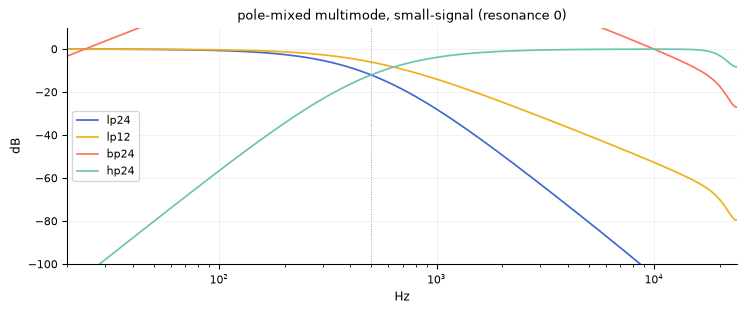

In [2]:
fc = 500.0
fig, ax = plt.subplots()
slopes = {}
modes = [("lp24", tap.Ladder.LP24, PAL[0]), ("lp12", tap.Ladder.LP12, PAL[1]),
         ("bp24", tap.Ladder.BP24, PAL[2]), ("hp24", tap.Ladder.HP24, PAL[3])]
for name, mode, color in modes:
    f = tap.Ladder(fs, frequency=fc, resonance=0.0, mode=mode)
    freqs, db = bode_small(f)
    db = db - db_at(freqs, db, fc / 20 if name.startswith("lp") else fc * 20)  # normalize passband
    # slope 2-3 octaves above fc, well below Nyquist (the bilinear zero at fs/2
    # steepens the far top end — true of any digital filter, not the claim here)
    slopes[name] = db_at(freqs, db, 2000) - db_at(freqs, db, 4000)
    ax.semilogx(freqs[1:], db[1:], color=color, lw=1.3, label=name)
print(f"high-side slopes: lp24 {slopes['lp24']:.1f} dB/oct (want 24), "
      f"lp12 {slopes['lp12']:.1f} (want 12)")
assert abs(slopes["lp24"] - 24) < 2.5
assert abs(slopes["lp12"] - 12) < 2.5
ax.axvline(fc, color="0.6", lw=0.7, ls=":")
ax.set(xlim=(20, 24000), ylim=(-100, 10), xlabel="Hz", ylabel="dB",
       title="pole-mixed multimode, small-signal (resonance 0)")
ax.legend()
plt.show()

## 2. Self-oscillation stays in tune — top octave included

Past resonance 1.0 the loop gain exceeds unity and the filter sings at the cutoff,
amplitude-bounded by the tanh stages. The ZDF prewarp is what keeps the oscillation
*in tune* at high cutoffs — the classic Stilson/Smith model (our `tap.fourpole~`)
goes audibly flat up there. The kernel suite pins ±3% at 1 kHz **and** 8 kHz; we
reproduce both.

cutoff  1000 Hz -> oscillates at  1000.2 Hz (0.02% error), peak |y| = 0.10
cutoff  8000 Hz -> oscillates at  8009.0 Hz (0.11% error), peak |y| = 0.10


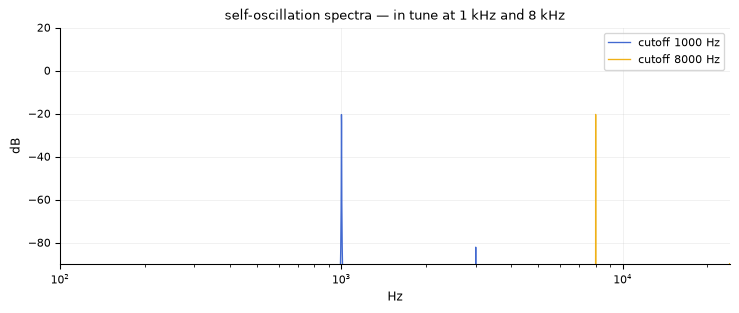

In [3]:
fig, ax = plt.subplots()
for i, fc in enumerate((1000.0, 8000.0)):
    f = tap.Ladder(fs, frequency=fc, resonance=1.08)
    ping = np.zeros(2 * fs)
    ping[0] = 0.5
    y = f.process(ping)
    tail = y[fs:]
    osc = peak_freq(tail)
    err = abs(osc - fc) / fc
    print(f"cutoff {fc:5.0f} Hz -> oscillates at {osc:7.1f} Hz ({100 * err:.2f}% error), "
          f"peak |y| = {np.abs(tail).max():.2f}")
    assert err < 0.03
    assert np.abs(tail).max() < 8.0
    fr, db = spectrum_db(tail)
    ax.semilogx(fr[1:], db[1:], color=PAL[i], lw=1.0, label=f"cutoff {fc:.0f} Hz")
ax.set(xlim=(100, 24000), ylim=(-90, 20), xlabel="Hz", ylabel="dB",
       title="self-oscillation spectra — in tune at 1 kHz and 8 kHz")
ax.legend()
plt.show()

## 3. Drive saturates progressively; asym adds the even harmonics

Drive pushes the signal into the per-stage tanh — THD must rise monotonically with
it, all odd harmonics (a symmetric nonlinearity). The `asym` control shifts every
stage's operating point (modeling transistor mismatch): at 0 the 2nd harmonic is
essentially absent; engaged, it appears orders of magnitude up — the even-harmonic
warmth of real hardware.

THD vs drive: 0 dB -> 0.54%, 8 dB -> 3.45%, 16 dB -> 16.50%, 24 dB -> 33.07%
2nd harmonic rel. fundamental: asym 0 -> -155.8 dB, asym 0.6 -> -18.6 dB


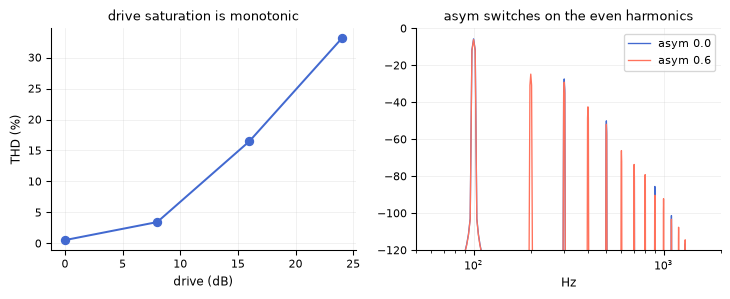

In [4]:
t = np.arange(fs) / fs
tone = 0.3 * np.sin(2 * np.pi * 100 * t)

drives = [0, 8, 16, 24]
thds = []
for d in drives:
    f = tap.Ladder(fs, frequency=5000, resonance=0.2, drive=d)
    y = f.process(tone)[fs // 2:]
    fund = 10 ** (harmonic_db(y, 100, 1) / 20)
    partials = np.sqrt(sum(10 ** (harmonic_db(y, 100, k) / 10) for k in range(2, 11)))
    thds.append(100 * partials / fund)
print("THD vs drive:", ", ".join(f"{d} dB -> {t_:.2f}%" for d, t_ in zip(drives, thds)))
assert all(b > a for a, b in zip(thds, thds[1:]))

h2 = {}
for asym in (0.0, 0.6):
    f = tap.Ladder(fs, frequency=5000, resonance=0.2, drive=12, asym=asym)
    y = f.process(tone)[fs // 2:]
    h2[asym] = harmonic_db(y, 100, 2) - harmonic_db(y, 100, 1)
print(f"2nd harmonic rel. fundamental: asym 0 -> {h2[0.0]:.1f} dB, asym 0.6 -> {h2[0.6]:.1f} dB")
assert h2[0.6] > h2[0.0] + 30

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3.0))
ax0.plot(drives, thds, "o-", color=PAL[0])
ax0.set(xlabel="drive (dB)", ylabel="THD (%)", title="drive saturation is monotonic")
for asym, c in ((0.0, PAL[0]), (0.6, PAL[2])):
    f = tap.Ladder(fs, frequency=5000, resonance=0.2, drive=12, asym=asym)
    fr, db = spectrum_db(f.process(tone)[fs // 2:])
    ax1.semilogx(fr[1:], db[1:], color=c, lw=1.0, label=f"asym {asym}")
ax1.set(xlim=(50, 2000), ylim=(-120, 0), xlabel="Hz",
        title="asym switches on the even harmonics")
ax1.legend()
plt.show()

## 4. comp restores the resonance-induced passband droop

A real ladder trades passband level for resonance (the feedback subtracts from the
input). `comp` compensates: at 0 you get the authentic droop, at 1 the passband
comes back to unity.

passband at 100 Hz, resonance 0.9: comp 0 -> -13.2 dB, comp 1 -> +0.0 dB


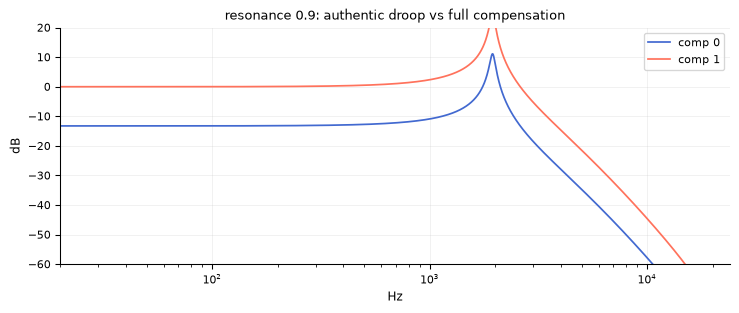

In [5]:
gains = {}
fig, ax = plt.subplots()
for comp, c in ((0.0, PAL[0]), (1.0, PAL[2])):
    f = tap.Ladder(fs, frequency=2000, resonance=0.9, comp=comp)
    freqs, db = bode_small(f)
    gains[comp] = db_at(freqs, db, 100)
    ax.semilogx(freqs[1:], db[1:], color=c, lw=1.3, label=f"comp {comp:.0f}")
print(f"passband at 100 Hz, resonance 0.9: comp 0 -> {gains[0.0]:+.1f} dB, "
      f"comp 1 -> {gains[1.0]:+.1f} dB")
assert gains[0.0] < -6
assert abs(gains[1.0]) < 1.5
ax.set(xlim=(20, 24000), ylim=(-60, 20), xlabel="Hz", ylabel="dB",
       title="resonance 0.9: authentic droop vs full compensation")
ax.legend()
plt.show()

## 5. Oversampling cuts the saturation's aliasing

The tanh stages generate harmonics past Nyquist that fold back as inharmonic alias
tones. Running the core at 4× (Butterworth anti-image/anti-alias cascades, the
`tap.verb~` pattern) pushes them down. We drive a 5 kHz tone hard and total the
energy at non-harmonic frequencies.

non-harmonic (alias) energy: 1x -> -30.1 dB, 4x -> -43.7 dB (reduction 13.5 dB)


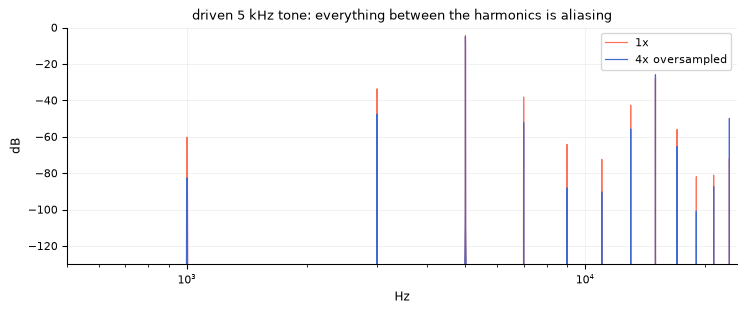


All tap.ladder~ claims verified against the shipping kernel.


In [6]:
t = np.arange(fs) / fs
tone = 0.5 * np.sin(2 * np.pi * 5000 * t)

def alias_energy(os):
    f = tap.Ladder(fs, frequency=12000, resonance=0.3, drive=20, oversample=os)
    y = f.process(tone)[fs // 2:]
    freqs, db = spectrum_db(y)
    p = 10 ** (db / 10)
    harm = np.zeros_like(freqs, bool)
    for k in range(1, 5):
        harm |= np.abs(freqs - 5000 * k) < 100
    band = (freqs > 500) & (freqs < 23000)
    return 10 * np.log10(p[band & ~harm].sum() + 1e-30), (freqs, db)

a1, (fr1, db1) = alias_energy(1)
a4, (fr4, db4) = alias_energy(4)
print(f"non-harmonic (alias) energy: 1x -> {a1:.1f} dB, 4x -> {a4:.1f} dB "
      f"(reduction {a1 - a4:.1f} dB)")
assert a1 - a4 > 6

fig, ax = plt.subplots()
ax.semilogx(fr1[1:], db1[1:], color=PAL[2], lw=0.9, label="1x")
ax.semilogx(fr4[1:], db4[1:], color=PAL[0], lw=0.9, label="4x oversampled")
ax.set(xlim=(500, 24000), ylim=(-130, 0), xlabel="Hz", ylabel="dB",
       title="driven 5 kHz tone: everything between the harmonics is aliasing")
ax.legend()
plt.show()

print("\nAll tap.ladder~ claims verified against the shipping kernel.")